Gerando Passo 1: Mapa de Densidade...


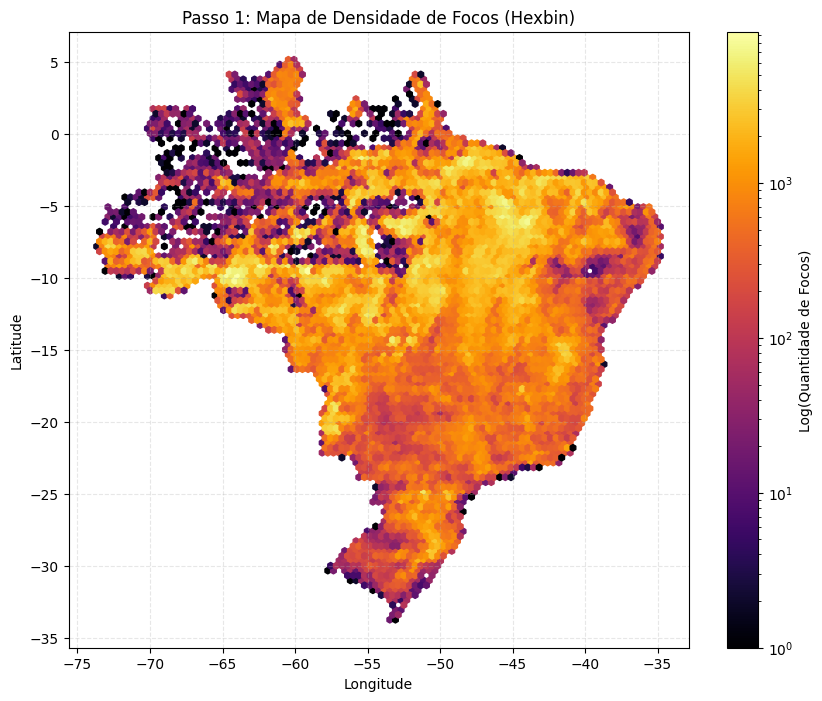

Gerando Passo 3: Agregação em Grelha (Grid)...


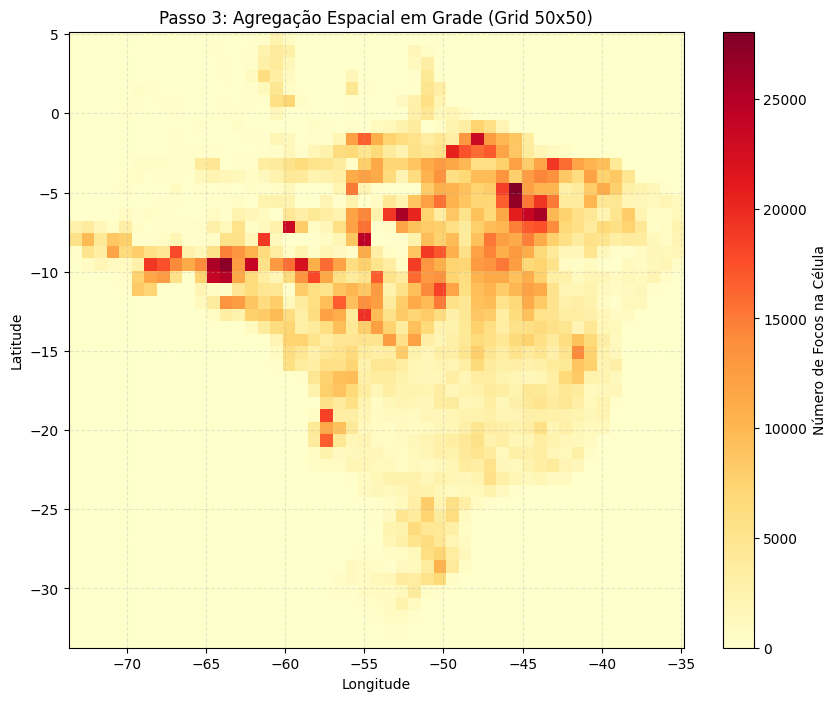

Gerando Passo 2: Cálculo e Scatterplot do Índice de Moran...
Índice de Moran Estimado na Grade: 0.7158


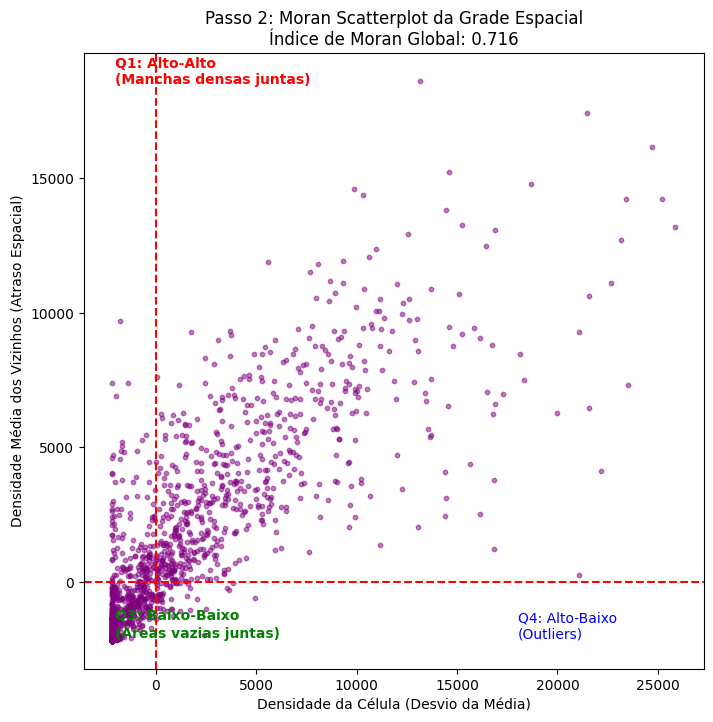

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =====================================================================
# CARREGANDO OS DADOS
# =====================================================================
# Certifique-se de que o arquivo CSV esteja na mesma pasta que o seu script
df = pd.read_csv('/home/avelaralencar/Desktop/zettaLab/data_focos_incendio/combined_focos_incendio.csv')

# =====================================================================
# PASSO 1: MAPA DE DENSIDADE (HEXBIN HEATMAP)
# =====================================================================
print("Gerando Passo 1: Mapa de Densidade...")
plt.figure(figsize=(10, 8))
# Usamos hexbin para agrupar as coordenadas em hexágonos coloridos pela densidade
hb = plt.hexbin(df['lon'], df['lat'], gridsize=100, cmap='inferno', bins='log', mincnt=1)
plt.colorbar(hb, label='Log(Quantidade de Focos)')
plt.title('Passo 1: Mapa de Densidade de Focos (Hexbin)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# =====================================================================
# PASSO 3 (Invertido por ser base do 2): AGREGAÇÃO ESPACIAL (GRID)
# =====================================================================
print("Gerando Passo 3: Agregação em Grelha (Grid)...")
# Criando 50 "fatias" de longitude e latitude (Grid 50x50)
lon_bins = np.linspace(df['lon'].min(), df['lon'].max(), 50)
lat_bins = np.linspace(df['lat'].min(), df['lat'].max(), 50)

# Calculando o Histograma 2D (quantos pontos em cada célula do grid)
H, xedges, yedges = np.histogram2d(df['lon'], df['lat'], bins=(lon_bins, lat_bins))

plt.figure(figsize=(10, 8))
# H.T transpõe a matriz para a orientação correta no mapa
plt.imshow(H.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='YlOrRd')
plt.colorbar(label='Número de Focos na Célula')
plt.title('Passo 3: Agregação Espacial em Grade (Grid 50x50)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# =====================================================================
# PASSO 2: AUTOCORRELAÇÃO ESPACIAL (ÍNDICE DE MORAN GLOBAL ESTIMADO)
# =====================================================================
print("Gerando Passo 2: Cálculo e Scatterplot do Índice de Moran...")

# Como não temos a biblioteca 'esda' instalada para usar shapefiles, 
# calculamos o Índice de Moran sobre a nossa grade matemática (Matriz H).

# Definindo a Vizinhança (Matriz de pesos W - 8 vizinhos ao redor da célula)
w = np.array([[1, 1, 1],
              [1, 0, 1],
              [1, 1, 1]])

# 1. Calculando os desvios em relação à média geral da grade
H_mean = np.mean(H)
z = H - H_mean

# 2. Denominador: Somatório das variâncias
S0 = np.sum(z**2)

# 3. Vizinhança Espacial: Atraso Espacial (Spatial Lag)
# Usa convolução para somar os valores (desvios z) dos 8 vizinhos de cada célula
z_lag = signal.convolve2d(z, w, mode='same', boundary='fill', fillvalue=0)

# 4. Numerador da fórmula de Moran
num = np.sum(z * z_lag)

# 5. Calculando o total de pesos da matriz de vizinhança
W_matrix = signal.convolve2d(np.ones_like(H), w, mode='same', boundary='fill', fillvalue=0)
W_total = np.sum(W_matrix)

# Número total de observações na grade (50x50 = 2500)
N = H.size 

# 6. Fórmula Final do Índice de Moran Global
morans_I = (N / W_total) * (num / S0)
print(f"Índice de Moran Estimado na Grade: {morans_I:.4f}")

# 7. Plotando o Moran Scatterplot
plt.figure(figsize=(8, 8))
# Plotamos o desvio de cada célula (Eixo X) contra a média dos desvios dos seus vizinhos (Eixo Y)
plt.scatter(z.flatten(), (z_lag / 8).flatten(), s=10, alpha=0.5, c='purple') 
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='red', linestyle='--')
plt.title(f'Passo 2: Moran Scatterplot da Grade Espacial\nÍndice de Moran Global: {morans_I:.3f}')
plt.xlabel('Densidade da Célula (Desvio da Média)')
plt.ylabel('Densidade Média dos Vizinhos (Atraso Espacial)')
plt.text(0.05, 0.95, 'Q1: Alto-Alto\n(Manchas densas juntas)', transform=plt.gca().transAxes, color='red', weight='bold')
plt.text(0.70, 0.05, 'Q4: Alto-Baixo\n(Outliers)', transform=plt.gca().transAxes, color='blue')
plt.text(0.05, 0.05, 'Q3: Baixo-Baixo\n(Áreas vazias juntas)', transform=plt.gca().transAxes, color='green', weight='bold')
plt.show()